# Tagging "democratic"

In this notebook, I will be focusing solely on "democratic," as we have definitions already set out by EE. I am firstly going to use the `.csv` file containing unique bigrams. In EE, they examine this by having a group of researchers work on labeling the bigrams, agreeing, then taking note of their agreement rates. Since I don't have a team, I have decided to use Mistral and Llama. I initially tried to approach this with Claude and Gemini APIs -- they seemed like better-trained models -- but well, those models weren't free! So I ended up installing free local LLMs instead: Mistral and Llama (llama3).

_On a side note_: would be interesting to use modeling to make 6 categories for each word, including "democratic," and see how that compares with the categorizations that they came up with in EE. One thing I have to check out is how literature-based the definitions in EE are. Like, did they come up with those 6 categories after seeing the bigrams, or based on how someone else has divided up / classified "democratic."

## Tagging unique bigrams

With the `.csv` files produced in my last notebook, I isolated just "democratic" bigrams and I can now start tagging them. Here, I am asking Mistral and Llama to simply tag the bigrams (without KWIC context stuff) and provide some reasons why. I'd like to expand this to the other terms, but for what it's worth, let's work with a word that we already have classifications for. There are 82 unique "democratic" bigrams -- a little less than I'd expected. But I suppose many terms were repeated.

In [ ]:
import requests
import pandas as pd
import time
import re

df = pd.read_csv('/Users/inqfinity/mip/democratic_ all_unique_bigrams_for_coding - Sheet1.csv', sep=";") #i manually isolated just the "democratic" unique bigrams
print(df.columns.tolist())

prompt = """
You are presented with bigrams related to "democratic" that are derived from a corpus of lemmatized UK parliamentary speeches. Tag bigrams based on these definitions and assign one category number only.

1. Party affiliation: when bigrams referred to UK parliamentary party names, for parties between 1980-2019 (e.g. democratic unionist)
2. International divisions: where "democratic" is used as a reference to countries (e.g. [German] Democratic Republic)
3. Constitutional issues: referring to state institutions and political questions (e.g. democratic structures)
4. Democratic principles: democratic principles for broad ideas and categories (e.g. democratic legitimacy)
5. Procedures and practices: procedures and practices when linked to specific processes (e.g. democratic vote)
6. Societal issues: societal issues when discussing broad societal topics (e.g. democratic community)

Note that bigrams have already been lemmatized and isolated out of the full context of their original speeches.

Reply in this exact format and nothing else:
Category: [single digit 1-6]
Reason: [10 words max]
"""

def tag_with_mistral(bigram):
    response = requests.post("http://localhost:11434/api/generate", json={"model": "mistral", "prompt": f"{prompt}\n\nBigram to code: \"{bigram}\"", "stream": False, "options": {"temperature": 0}} )
    raw = response.json()["response"].strip()
    code_match = re.search(r'Category:\s*([1-6])', raw)
    reason_match = re.search(r'Reason:\s*(.+)', raw)
    code = code_match.group(1) if code_match else re.search(r'[1-6]', raw).group() if re.search(r'[1-6]', raw) else "NA"
    reason = reason_match.group(1).strip() if reason_match else "NA"
    return code, reason

def tag_with_llama(bigram):
    response = requests.post("http://localhost:11434/api/generate", json={"model": "llama3", "prompt": f"{prompt}\n\nBigram to code: \"{bigram}\"", "stream": False, "options": {"temperature": 0}})
    raw = response.json()["response"].strip()
    code_match = re.search(r'Category:\s*([1-6])', raw)
    reason_match = re.search(r'Reason:\s*(.+)', raw)
    code = code_match.group(1) if code_match else re.search(r'[1-6]', raw).group() if re.search(r'[1-6]', raw) else "NA"
    reason = reason_match.group(1).strip() if reason_match else "NA"
    return code, reason

mistral_codes, mistral_reasons = [], []
llama_codes, llama_reasons = [], []

for i, row in df.iterrows():
    bigram = row["bigram"]

    m_code, m_reason = tag_with_mistral(bigram)
    l_code, l_reason = tag_with_llama(bigram)

    mistral_codes.append(m_code)
    mistral_reasons.append(m_reason)
    llama_codes.append(l_code)
    llama_reasons.append(l_reason)

    print(f"[{i+1}/{len(df)}] '{bigram}' | Mistral: {m_code} ({m_reason}) | Llama: {l_code} ({l_reason})")
    time.sleep(0.3)

df["category_code_mistral"] = mistral_codes
df["category_code_mistral_reason"] = mistral_reasons
df["category_code_llama"] = llama_codes
df["category_code_llama_reason"] = llama_reasons

df.to_csv("/Users/inqfinity/mip/democratic_bigrams_tagged_comparison.csv", index=False)
print("\nSaved: democratic_bigrams_tagged_comparison.csv")

['target_word', 'bigram', 'total_count', 'periods_present', 'periods_list', 'category_code']
[1/82] 'democratic process' | Mistral: 5 (Refers to a specific democratic procedure.) | Llama: 5 (Procedures and practices linked to specific processes.)
[2/82] 'social democratic' | Mistral: 4 (Refers to a political ideology combining elements of socialism and democracy.) | Llama: 4 (Refers to broad democratic principles.)
[3/82] 'democratic party' | Mistral: 1 (Refers to UK parliamentary party name.) | Llama: 1 (Party affiliation, UK parliamentary party name.)
[4/82] 'democratic unionist' | Mistral: 1 (Refers to UK parliamentary party name (Democratic Unionist Party)) | Llama: 1 (Party affiliation, UK parliamentary party name.)
[5/82] 'democratic accountability' | Mistral: 4 (Refers to democratic principles.) | Llama: 4 (Refers to democratic principles for broad ideas.)
[6/82] 'democratic right' | Mistral: 5 (Refers to a specific democratic practice or procedure.) | Llama: 5 (Procedures and p

After asking Llama and Mistral to tag (and give reasons, which I find to very much be a "fork found in the kitchen" kind of reasoning), I manually modified the `.csv` to include my own rankings, and saved it as a new file. Now, I can not only visualize my thematic classifications of the bigrams, but also compare my rankings to that of the LLMs.

  target_word                     bigram  total_count  periods_present  \
0  democratic         democratic process         3516                4   
1  democratic          social democratic         2480                4   
2  democratic           democratic party         2002                4   
3  democratic        democratic unionist         1791                4   
4  democratic  democratic accountability         1708                4   

                                 periods_list  category_code  \
0  1980_1989, 1990_1999, 2000_2009, 2010_2019              5   
1  1980_1989, 1990_1999, 2000_2009, 2010_2019              4   
2  1980_1989, 1990_1999, 2000_2009, 2010_2019              1   
3  1980_1989, 1990_1999, 2000_2009, 2010_2019              1   
4  1980_1989, 1990_1999, 2000_2009, 2010_2019              4   

   category_code_mistral                       category_code_mistral_reason  \
0                      5         Refers to a specific democratic procedure.   
1           

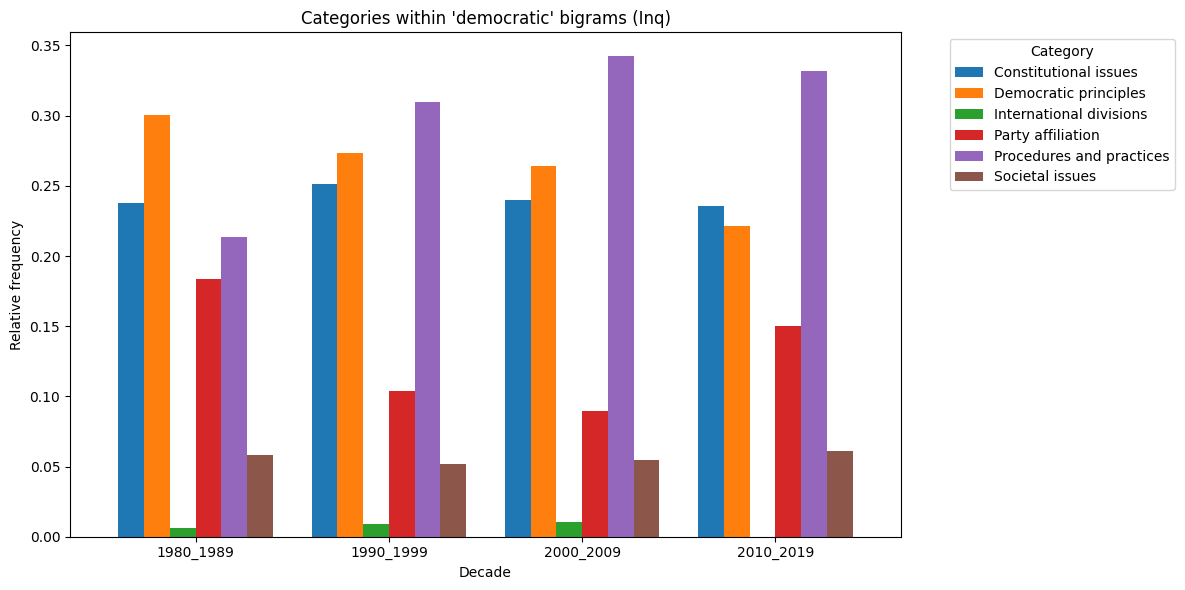

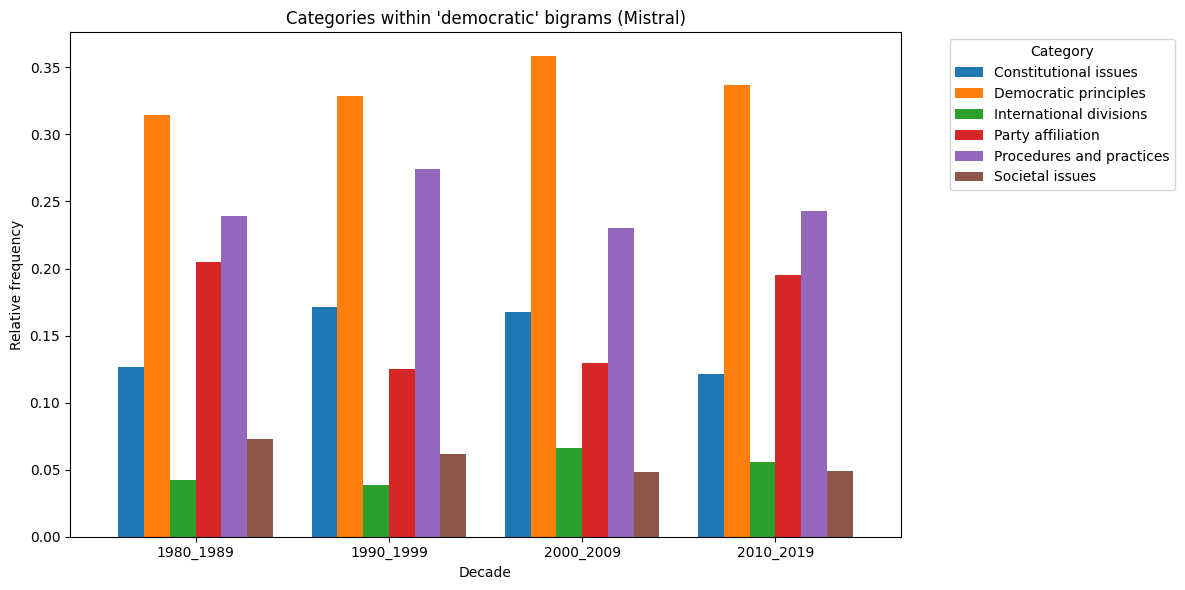

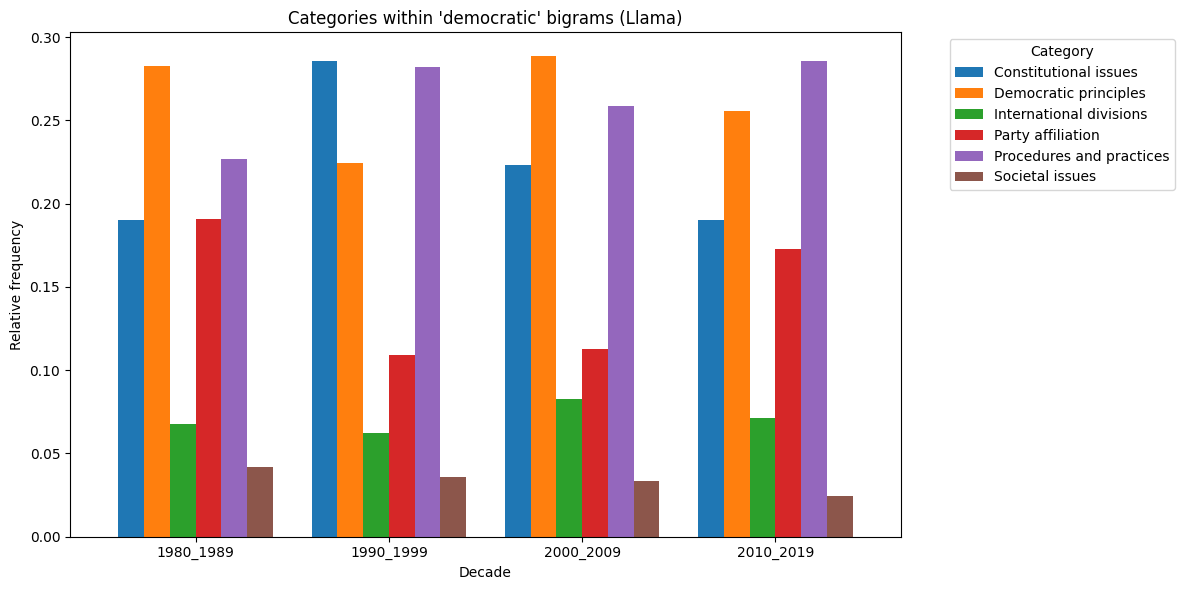

In [ ]:
import matplotlib.pyplot as plt
import glob
import os

tagged_path = "/Users/inqfinity/mip/democratic_bigrams_tagged_comparison_withme.csv"

bigram_folder = "/Users/inqfinity/mip/newdecades_bigram_outputs"

bigram_files = [f"{bigram_folder}/democratic_1980_1989_top50_bigrams.csv", f"{bigram_folder}/democratic_1990_1999_top50_bigrams.csv", f"{bigram_folder}/democratic_2000_2009_top50_bigrams.csv", f"{bigram_folder}/democratic_2010_2019_top50_bigrams.csv",]

#bring in the tagged dict

tags = pd.read_csv(tagged_path, sep=";")

tags = tags[tags["target_word"] == "democratic"].copy()

print(tags.head())
print(tags.columns)

all_decades = [] #bigram files (the ones by decade)

for file in bigram_files:
    df = pd.read_csv(file)
    all_decades.append(df)

bigrams = pd.concat(all_decades, ignore_index=True)

bigrams = bigrams[bigrams["target_word"] == "democratic"].copy()

print(bigrams.head())

merged = bigrams.merge(tags[["bigram", "category_code", "category_code_mistral", "category_code_llama"]], on="bigram", how="left")

print(merged.head())
print("Unmatched bigrams:", merged["category_code"].isna().sum())

category_names = {1: "Party affiliation", 2: "International divisions", 3: "Constitutional issues", 4: "Democratic principles", 5: "Procedures and practices", 6: "Societal issues"}

def plot_category_bars(df, label_col, model_name): #agg and plot

    plot_df = df.dropna(subset=[label_col]).copy()

    plot_df[label_col] = plot_df[label_col].astype(int)

    plot_df["category"] = plot_df[label_col].map(category_names)

    grouped = (plot_df.groupby(["period", "category"], as_index=False)["count"].sum())

    grouped["relative_frequency"] = (grouped["count"] / grouped.groupby("period")["count"].transform("sum")) #normalize

    wide = grouped.pivot(index="period", columns="category", values="relative_frequency").fillna(0) #pivot for plotting

    wide = wide.reindex(["1980_1989", "1990_1999", "2000_2009", "2010_2019"]) #keep chorno order!!

    ax = wide.plot(kind="bar", figsize=(12, 6), width=0.8)

    plt.title(f"Categories within 'democratic' bigrams ({model_name})")

    plt.xlabel("Decade")
    plt.ylabel("Relative frequency")

    plt.xticks(rotation=0)

    plt.legend(title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.show()

    return grouped, wide

human_grouped, human_wide = plot_category_bars(merged, "category_code", "Inq")
mistral_grouped, mistral_wide = plot_category_bars(merged, "category_code_mistral", "Mistral")
llama_grouped, llama_wide = plot_category_bars(merged, "category_code_llama", "Llama")

### Remark on AI use (in making plots look nicer)

Same disclaimer goes with my prior notebooks: I don't want to spend time prettyfying all my plots, so I used AI to fix up the aesthetics. (Yes, I do know how to use packages like seaborn and do this on my own, but I honestly don't have the time to tweak things. I am also a little too perfectionistic when I try to make plots or presentations look nice.)

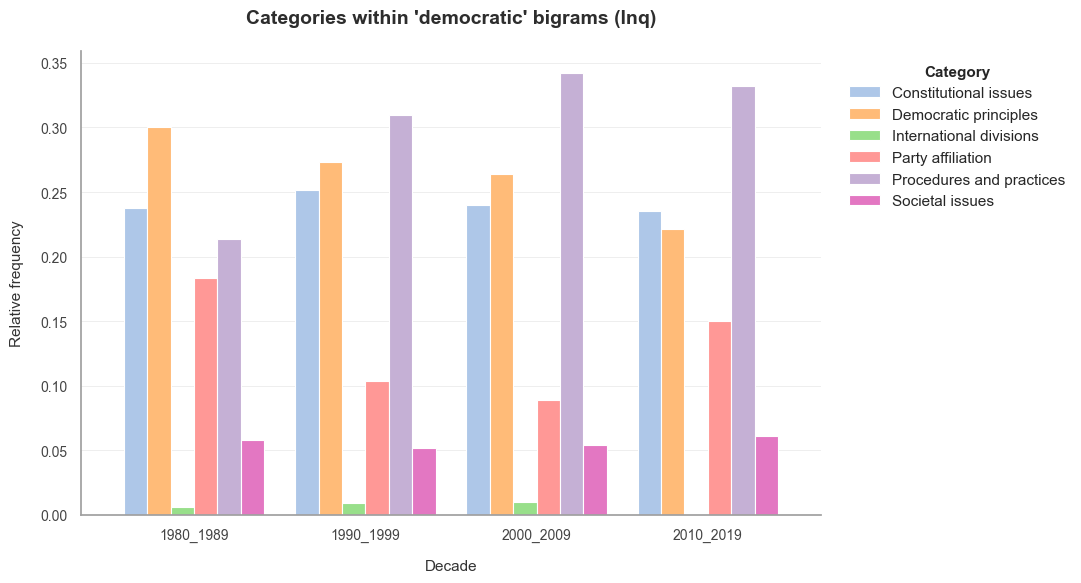

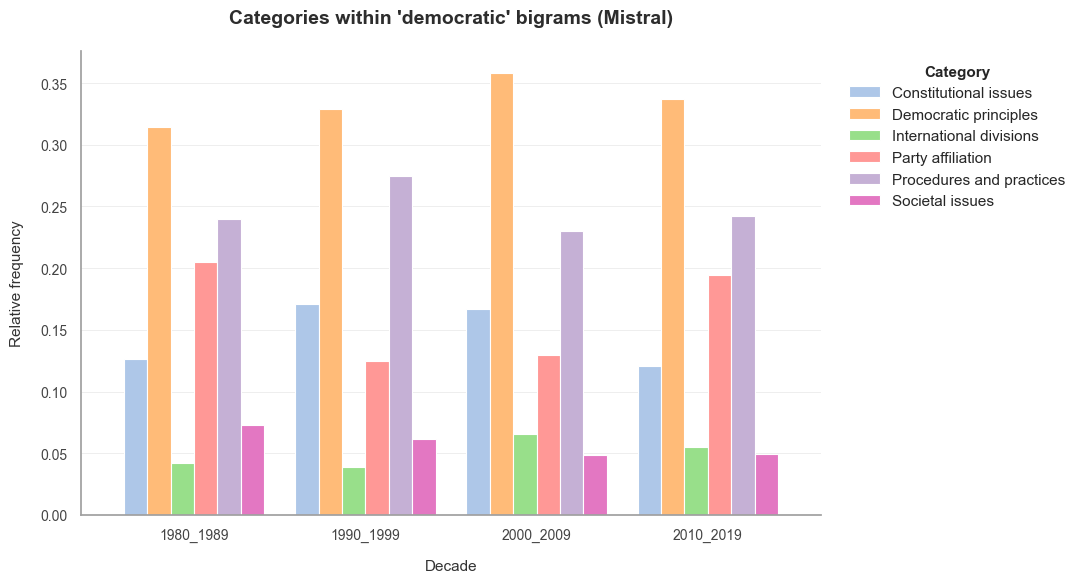

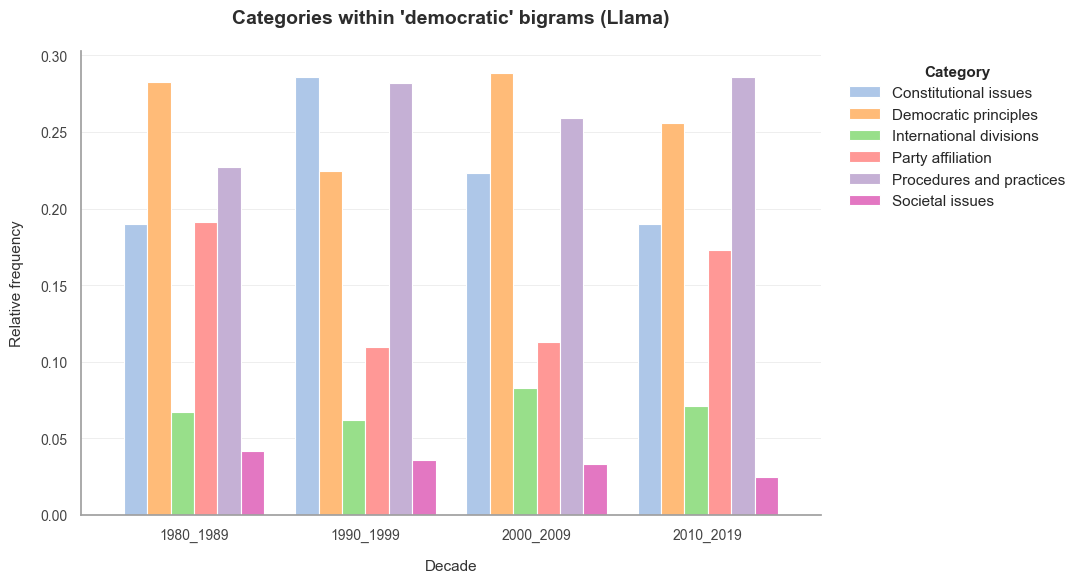

In [3]:
import seaborn as sns

def plot_category_bars_distinct_pastel(df, label_col, model_name):
    plot_df = df.dropna(subset=[label_col]).copy()
    plot_df[label_col] = plot_df[label_col].astype(int)
    plot_df["category"] = plot_df[label_col].map(category_names)

    grouped = (
        plot_df
        .groupby(["period", "category"], as_index=False)["count"]
        .sum()
    )

    # Normalize
    grouped["relative_frequency"] = (grouped["count"] / grouped.groupby("period")["count"].transform("sum"))

    # Pivot for plotting
    wide = grouped.pivot(index="period", columns="category", values="relative_frequency").fillna(0)
    wide = wide.reindex(["1980_1989", "1990_1999", "2000_2009", "2010_2019"])

    # --- DISTINCT PASTEL AESTHETIC UPGRADES ---
    
    # 1. Set clean background
    sns.set_theme(style="white") 
    
    # 2. Distinct Pastel Palette
    # Soft, matte pastel colors that are easily distinguishable from one another
    distinct_pastels = [
        "#AEC7E8",  # Soft Sky Blue
        "#FFBB78",  # Pale Apricot
        "#98DF8A",  # Sage Green
        "#FF9896",  # Dusty Rose
        "#C5B0D5",  # Light Lavender
        "#E377C2"   # Soft Mauve/Pink
    ]
    
    # 3. Create the plot with a clean white gap between categories
    fig, ax = plt.subplots(figsize=(11, 6), dpi=100)
    wide.plot(
        kind="bar", 
        width=0.82, 
        color=distinct_pastels, 
        ax=ax, 
        edgecolor="white",  # A clean white border sets the pastels apart nicely
        linewidth=0.8
    )

    # 4. Clean background grids
    ax.set_axisbelow(True) 
    ax.yaxis.grid(True, color="#EBEBEB", linestyle="-", linewidth=0.6) 
    ax.xaxis.grid(False) 
    
    # Despine top and right
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color("#A0A0A0")
    ax.spines["bottom"].set_color("#A0A0A0")

    # 5. Crisp Typography
    plt.title(f"Categories within 'democratic' bigrams ({model_name})", fontsize=14, pad=20, weight="bold", color="#2D2D2D")
    plt.xlabel("Decade", fontsize=11, labelpad=12, color="#333333")
    plt.ylabel("Relative frequency", fontsize=11, labelpad=12, color="#333333")
    
    plt.xticks(rotation=0, fontsize=10, color="#444444")
    plt.yticks(fontsize=10, color="#444444")

    # 6. Clean Legend
    plt.legend(
        title="Category", 
        bbox_to_anchor=(1.02, 1), 
        loc="upper left", 
        frameon=False, 
        title_fontproperties={"weight": "bold", "size": 11}
    )

    plt.tight_layout()
    plt.show()
    
    # Reset seaborn style to default
    sns.reset_orig()

    return grouped, wide

# Run the distinct pastel version on your data
human_grouped, human_wide = plot_category_bars_distinct_pastel(merged, "category_code", "Inq")
mistral_grouped, mistral_wide = plot_category_bars_distinct_pastel(merged, "category_code_mistral", "Mistral")
llama_grouped, llama_wide = plot_category_bars_distinct_pastel(merged, "category_code_llama", "Llama")

## Cohen's Kappa
Of course, we don't just want to compare graphs! We also want to measure the agreeableness in a more statistical way. Evidently, the LLMs are the most consistent between each other. It definitely makes me question my own labelling, as I often categorized what I felt unsure about into democratic procedures, as that is a vague-enough category. As aforementioned, there were many instances where a word could be many categories at once. On my blog, you can see a table that helps interpret the Kappa.

In [26]:
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

agreement_df = tags.dropna(subset=["category_code", "category_code_mistral", "category_code_llama"]).copy() #keep rows that got labels

agreement_df["category_code"] = agreement_df["category_code"].astype(int)
agreement_df["category_code_mistral"] = agreement_df["category_code_mistral"].astype(int)
agreement_df["category_code_llama"] = agreement_df["category_code_llama"].astype(int)

human_vs_mistral = cohen_kappa_score(agreement_df["category_code"], agreement_df["category_code_mistral"]) #not sure if this is the best way to measure agreement but ok

human_vs_llama = cohen_kappa_score(agreement_df["category_code"], agreement_df["category_code_llama"])

mistral_vs_llama = cohen_kappa_score(agreement_df["category_code_mistral"], agreement_df["category_code_llama"])

print("Inq vs. Mistral kappa:", round(human_vs_mistral, 3))
print("Inq vs. Llama kappa:", round(human_vs_llama, 3))
print("Mistral vs. Llama kappa:", round(mistral_vs_llama, 3))

Inq vs. Mistral kappa: 0.366
Inq vs. Llama kappa: 0.296
Mistral vs. Llama kappa: 0.602


I also used a confusion matrix to help visualize the "agreed" upon counts. (Sorry if I'm not explaining so much here, I came back to label this notebook after writing blog entries, so it's starting to sound redundant to me.)

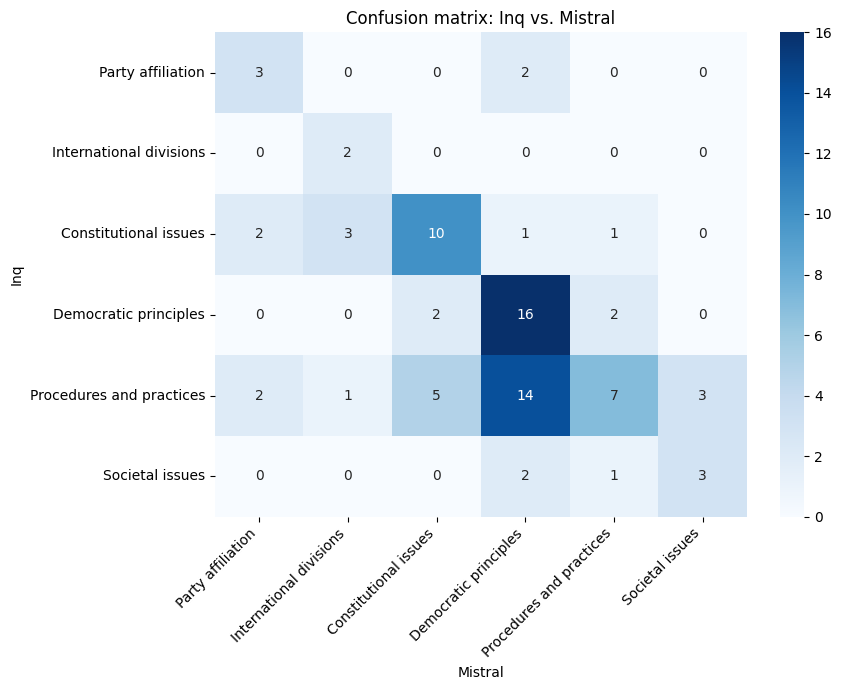

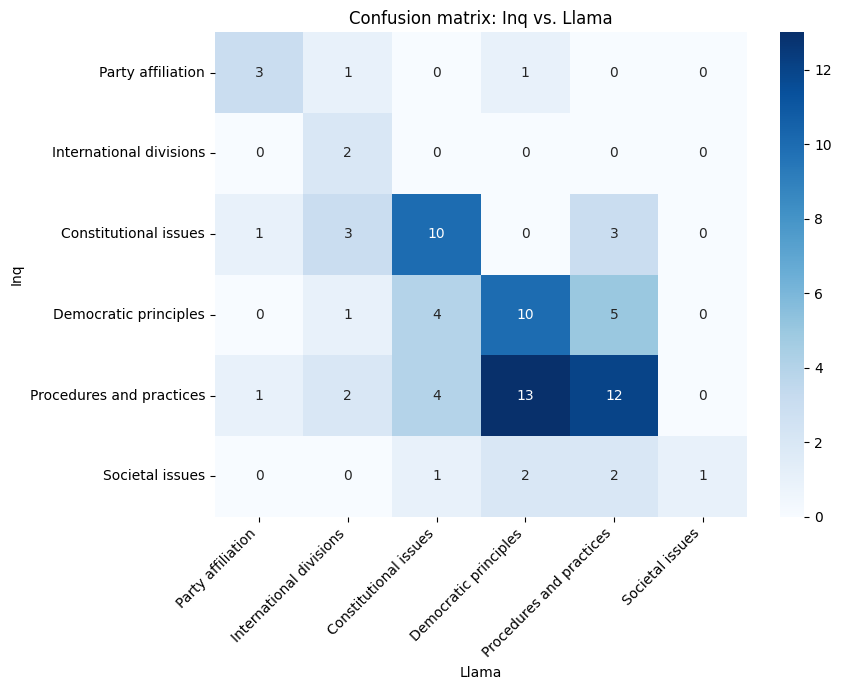

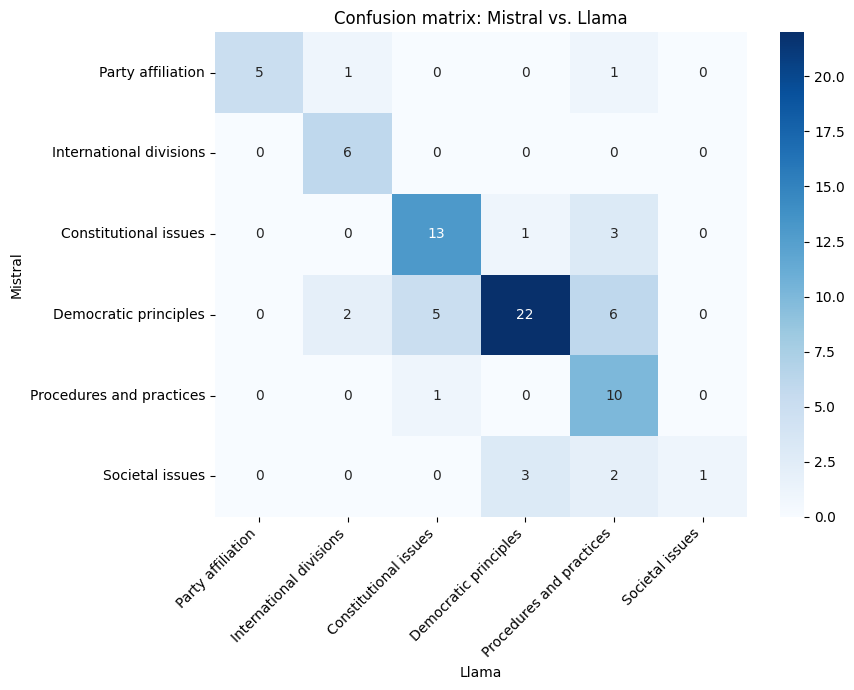

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

agreement_df = tags.dropna(subset=["category_code", "category_code_mistral", "category_code_llama"]).copy()

agreement_df["category_code"] = agreement_df["category_code"].astype(int)
agreement_df["category_code_mistral"] = agreement_df["category_code_mistral"].astype(int)
agreement_df["category_code_llama"] = agreement_df["category_code_llama"].astype(int)

category_names = {
    1: "Party affiliation",
    2: "International divisions",
    3: "Constitutional issues",
    4: "Democratic principles",
    5: "Procedures and practices",
    6: "Societal issues"
}

labels = list(category_names.keys())
label_names = list(category_names.values())

def plot_confusion_matrix(y_true, y_pred, title, xlabel, ylabel):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(9, 7))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(agreement_df["category_code"], agreement_df["category_code_mistral"], "Confusion matrix: Inq vs. Mistral", "Mistral", "Inq")
plot_confusion_matrix(agreement_df["category_code"], agreement_df["category_code_llama"], "Confusion matrix: Inq vs. Llama", "Llama", "Inq")
plot_confusion_matrix(agreement_df["category_code_mistral"], agreement_df["category_code_llama"], "Confusion matrix: Mistral vs. Llama", "Llama", "Mistral")

Asked AI to make that code block plot more aesthetically.

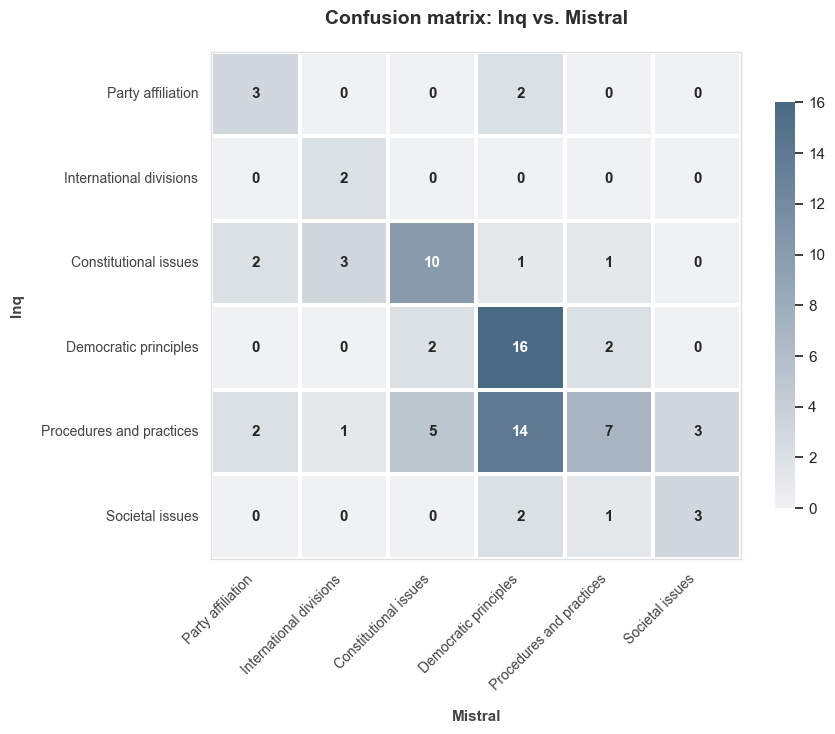

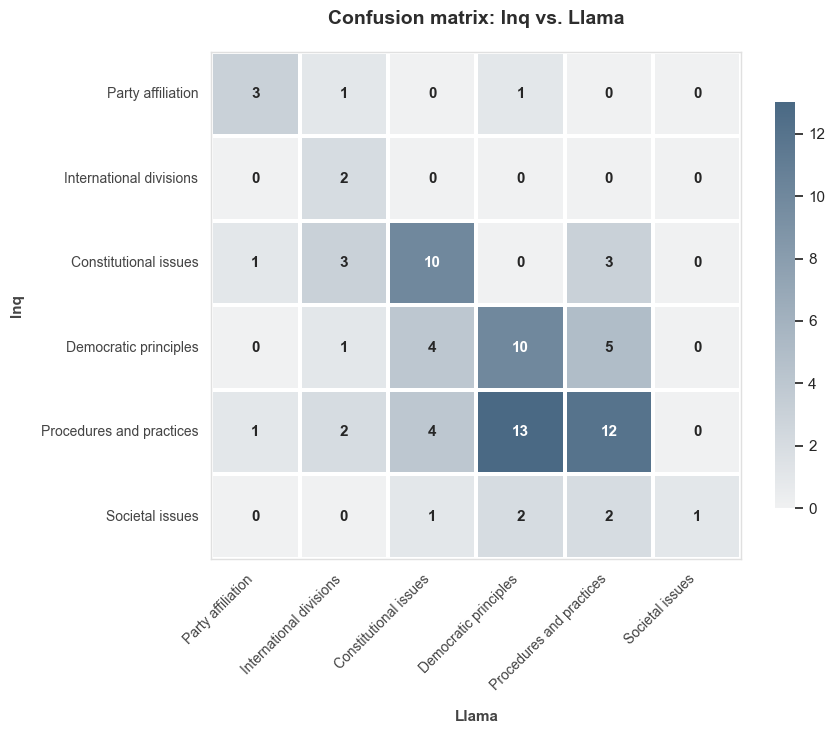

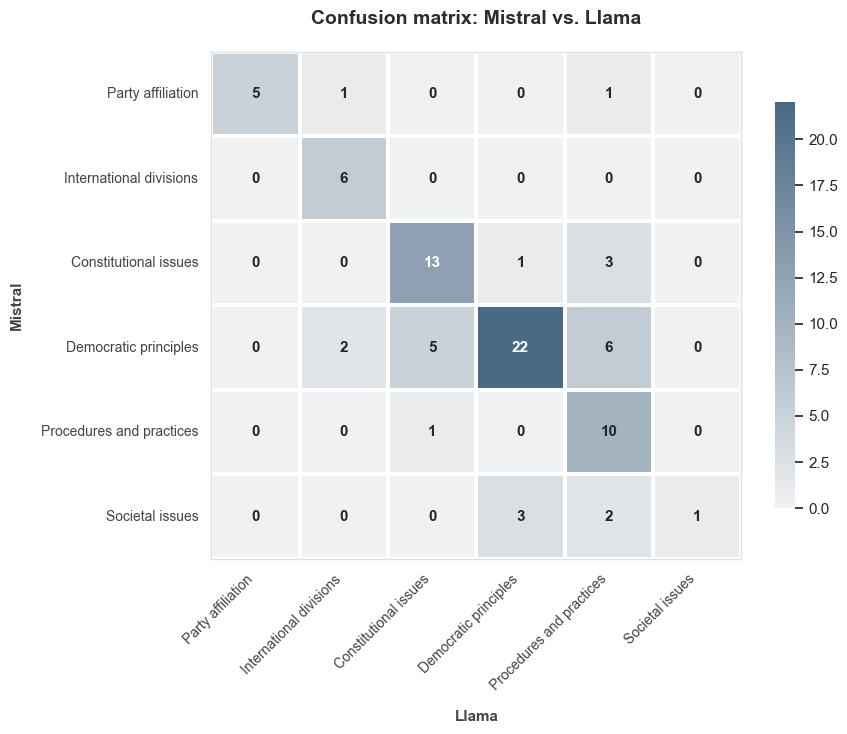

In [35]:
def plot_confusion_matrix_pretty(y_true, y_pred, title, xlabel, ylabel):
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=labels
    )

    # 1. Set clean style context
    sns.set_theme(style="white")
    plt.figure(figsize=(9, 7.5), dpi=100)

    # 2. Use a sophisticated, modern sequential color palette 
    # 'mako' or 'Purples' gives a great high-end look while staying clear
    custom_cmap = sns.light_palette("#4A6984", as_cmap=True) 

    # 3. Draw the heatmap with subtle white dividers between cells
    ax = sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=custom_cmap,
        xticklabels=label_names,
        yticklabels=label_names,
        linewidths=1.5,       # Crisper grid separation
        linecolor="white",    # Clean border lines between squares
        cbar_kws={"shrink": 0.8}, # Make the colorbar slightly more elegant
        annot_kws={"size": 11, "weight": "bold"} # Make matrix numbers pop
    )

    # 4. Refined Typography & Spacing
    plt.title(title, fontsize=14, pad=20, weight="bold", color="#2D2D2D")
    
    # Styled axis labels
    plt.xlabel(xlabel, fontsize=11, labelpad=12, weight="bold", color="#444444")
    plt.ylabel(ylabel, fontsize=11, labelpad=12, weight="bold", color="#444444")

    # Clean up tick alignments so they read easily
    plt.xticks(rotation=45, ha="right", fontsize=10, color="#444444")
    plt.yticks(rotation=0, fontsize=10, color="#444444")

    # 5. Border cleanup
    # Add a subtle frame back around the heatmap matrix itself
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_color("#E0E0E0")
        spine.set_linewidth(1)

    plt.tight_layout()
    plt.show()
    
    # Reset theme to default behavior
    sns.reset_orig()

# Run the updated pretty confusion matrices
plot_confusion_matrix_pretty(
    agreement_df["category_code"],
    agreement_df["category_code_mistral"],
    "Confusion matrix: Inq vs. Mistral",
    "Mistral",
    "Inq"
)

plot_confusion_matrix_pretty(
    agreement_df["category_code"],
    agreement_df["category_code_llama"],
    "Confusion matrix: Inq vs. Llama",
    "Llama",
    "Inq"
)

plot_confusion_matrix_pretty(
    agreement_df["category_code_mistral"],
    agreement_df["category_code_llama"],
    "Confusion matrix: Mistral vs. Llama",
    "Llama",
    "Mistral"
)

To better see how each of the 6 categories shifted over time, we can plot them as line graphs. Here, I also want to get relative frequencies (not just within the selected bigrams themselves that we did with the bar charts above), but relative to the **decades**. So, I have to recall the more original processed `.csv` files again to count our tagged bigrams properly, to see how they show up as a proportion of the decades within our entire corpus.

In [ ]:
from collections import Counter, defaultdict

tagged_path = "/Users/inqfinity/mip/democratic_bigrams_tagged_comparison_withme.csv"

corpus_folder = "/Users/inqfinity/mip/hansard_1979-2021/processed_csvs" #folder with processed corpus so that we can see the relative freqs among the entire thing (since our bigram csvs only have things like frequencies)

corpus_files = glob.glob(f"{corpus_folder}/*_processed.csv")

text_col = "speech_lemmatized"
year_col = "date"
target_word = "democratic"

category_names = {
    1: "Party affiliation",
    2: "International divisions",
    3: "Constitutional issues",
    4: "Democratic principles",
    5: "Procedures and practices",
    6: "Societal issues"
}

model_cols = {"Inq": "category_code", "Mistral": "category_code_mistral", "Llama": "category_code_llama"}

tags = pd.read_csv(tagged_path, sep=";")

tags = tags[tags["target_word"] == target_word].copy()
tags = tags.dropna(subset=["bigram"])

dictionary_bigrams = set(tags["bigram"])

print("Tagged democratic bigrams:", len(dictionary_bigrams))

def get_decade(year):
    year = int(year)
    if 1980 <= year <= 1989:
        return "1980_1989"
    elif 1990 <= year <= 1999:
        return "1990_1999"
    elif 2000 <= year <= 2009:
        return "2000_2009"
    elif 2010 <= year <= 2019:
        return "2010_2019"
    else:
        return None

def extract_bigrams(text):
    tokens = str(text).split()
    return [" ".join(pair) for pair in zip(tokens[:-1], tokens[1:])]

decade_total_bigrams = defaultdict(int) #relative freq per decade
decade_bigram_counts = defaultdict(Counter)

for file in corpus_files:
    print("Reading:", os.path.basename(file))
    df = pd.read_csv(file, low_memory=False)
    
    if "speech_class" in df.columns:
        df = df[df["speech_class"] == "Speech"].copy()
    
    df = df.dropna(subset=[text_col, year_col])
    
    for _, row in df.iterrows():
        year = int(str(row[year_col])[:4])
        decade = get_decade(year)
        
        if decade is None:
            continue
        
        bigrams = extract_bigrams(row[text_col])
        decade_total_bigrams[decade] += len(bigrams)
        matched = [bg for bg in bigrams if bg in dictionary_bigrams]
        decade_bigram_counts[decade].update(matched)

rows = []

for decade, counter in decade_bigram_counts.items():
    for bigram, count in counter.items():
        rows.append({"decade": decade, "bigram": bigram, "count": count, "total_decade_bigrams": decade_total_bigrams[decade]})

counts_df = pd.DataFrame(rows)
counts_df["relative_freq"] = (counts_df["count"] / counts_df["total_decade_bigrams"])

merged_full = counts_df.merge(tags[["bigram", "category_code", "category_code_mistral", "category_code_llama"]], on="bigram", how="left")

print(merged_full.head())

Tagged democratic bigrams: 82
Reading: 2011_processed.csv
Reading: 1989_processed.csv
Reading: 2006_processed.csv
Reading: 2002_processed.csv
Reading: 2015_processed.csv
Reading: 1979_processed.csv
Reading: 2005_processed.csv
Reading: 2012_processed.csv
Reading: 2016_processed.csv
Reading: 1999_processed.csv
Reading: 2001_processed.csv
Reading: 1993_processed.csv
Reading: 1984_processed.csv
Reading: 2021_processed.csv
Reading: 2018_processed.csv
Reading: 1980_processed.csv
Reading: 1997_processed.csv
Reading: 1987_processed.csv
Reading: 1990_processed.csv
Reading: 2008_processed.csv
Reading: 1994_processed.csv
Reading: 1983_processed.csv
Reading: 1982_processed.csv
Reading: 1995_processed.csv
Reading: 1991_processed.csv
Reading: 2009_processed.csv
Reading: 1986_processed.csv
Reading: 1996_processed.csv
Reading: 2019_processed.csv
Reading: 1981_processed.csv
Reading: 2020_processed.csv
Reading: 1985_processed.csv
Reading: 1992_processed.csv
Reading: 1998_processed.csv
Reading: 2000_proc

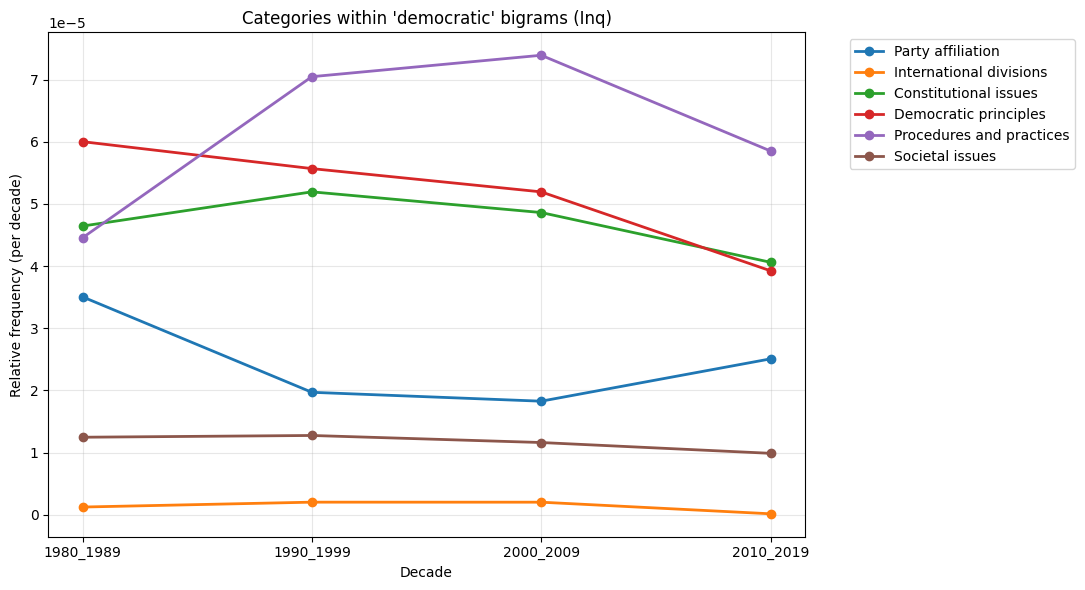

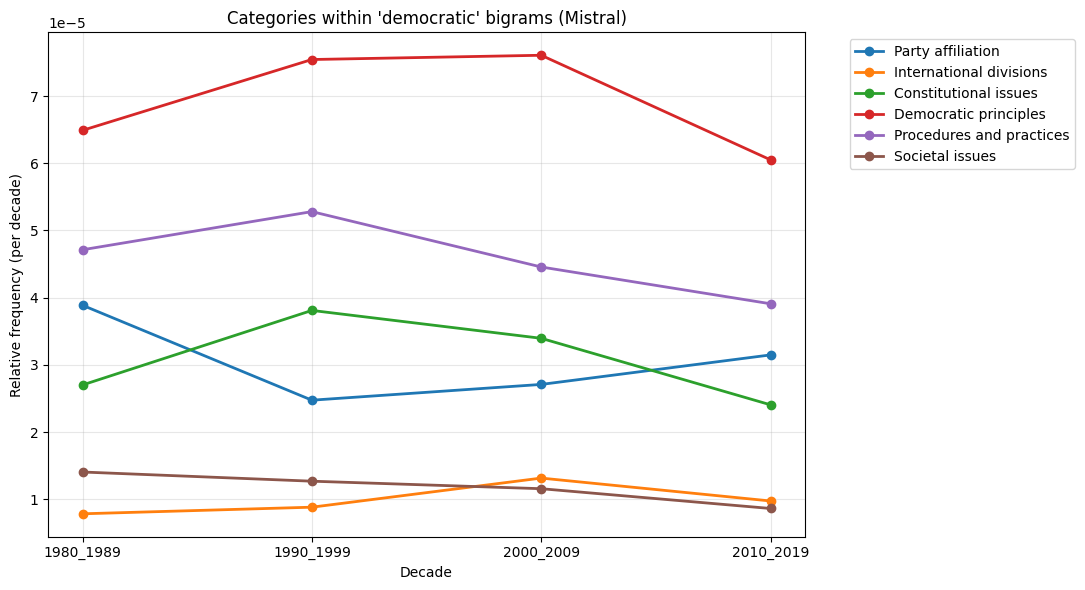

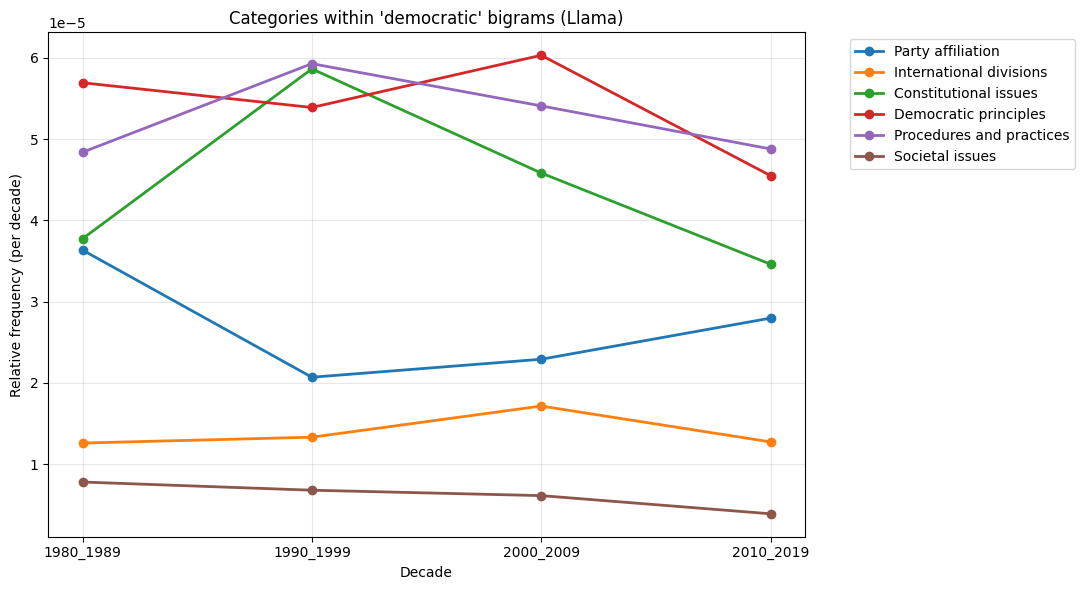

In [6]:
def plot_decade_corpus_relative_frequency(df, label_col, model_name):
    plot_df = df.dropna(subset=[label_col]).copy()
    plot_df[label_col] = plot_df[label_col].astype(int)
    plot_df["category"] = plot_df[label_col].map(category_names)
    grouped = (plot_df.groupby(["decade", "category"], as_index=False).agg(category_count=("count", "sum"), total_decade_bigrams=("total_decade_bigrams", "first")))
    grouped["relative_freq"] = (grouped["category_count"] / grouped["total_decade_bigrams"])

    wide = grouped.pivot(index="decade", columns="category", values="relative_freq").fillna(0)
    wide = wide.reindex(["1980_1989", "1990_1999", "2000_2009", "2010_2019"])
    
    plt.figure(figsize=(11, 6))
    
    for category in category_names.values():
        if category in wide.columns:
            plt.plot(wide.index, wide[category], marker="o", linewidth=2, label=category)

    plt.title(f"Categories within 'democratic' bigrams ({model_name})")
    plt.xlabel("Decade")
    plt.ylabel("Relative frequency (per decade)")
    plt.grid(True, alpha=0.3)
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
    
    return grouped, wide

decade_corpus_results = {}

for model_name, label_col in model_cols.items():
    grouped, wide = plot_decade_corpus_relative_frequency(merged_full, label_col, model_name)
    decade_corpus_results[model_name] = {"grouped": grouped, "wide": wide}

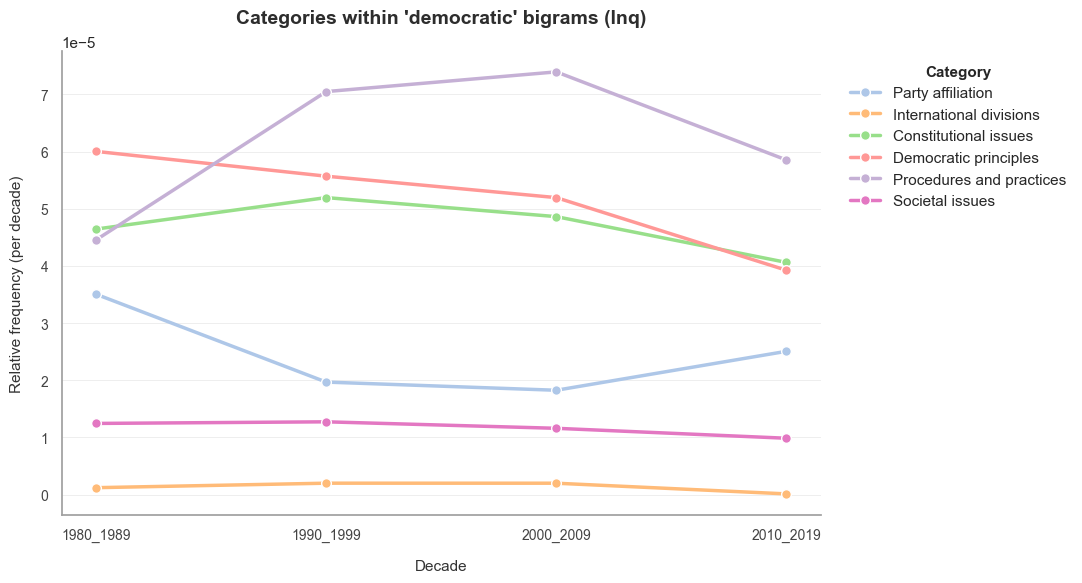

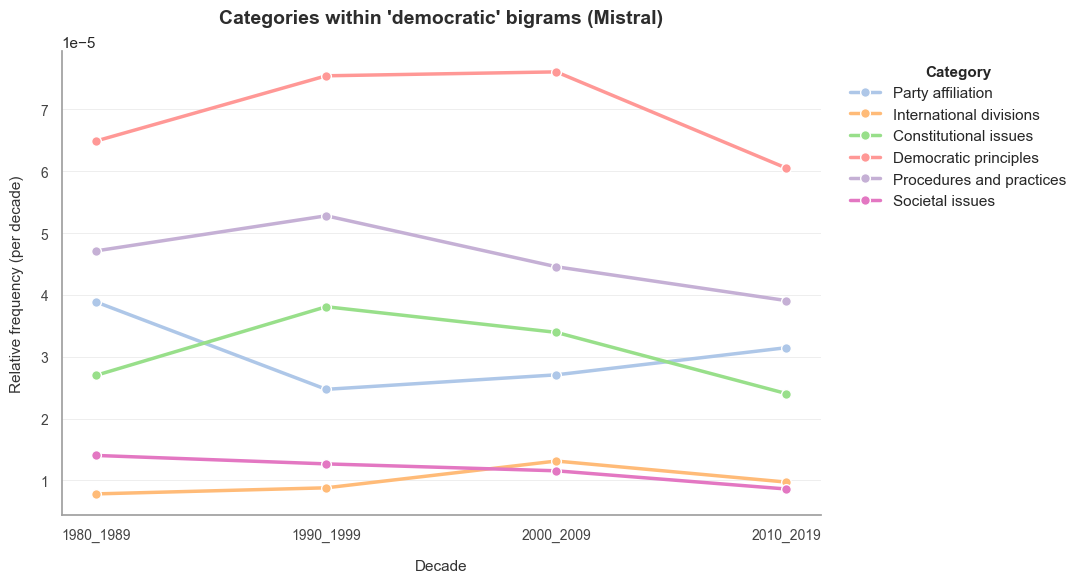

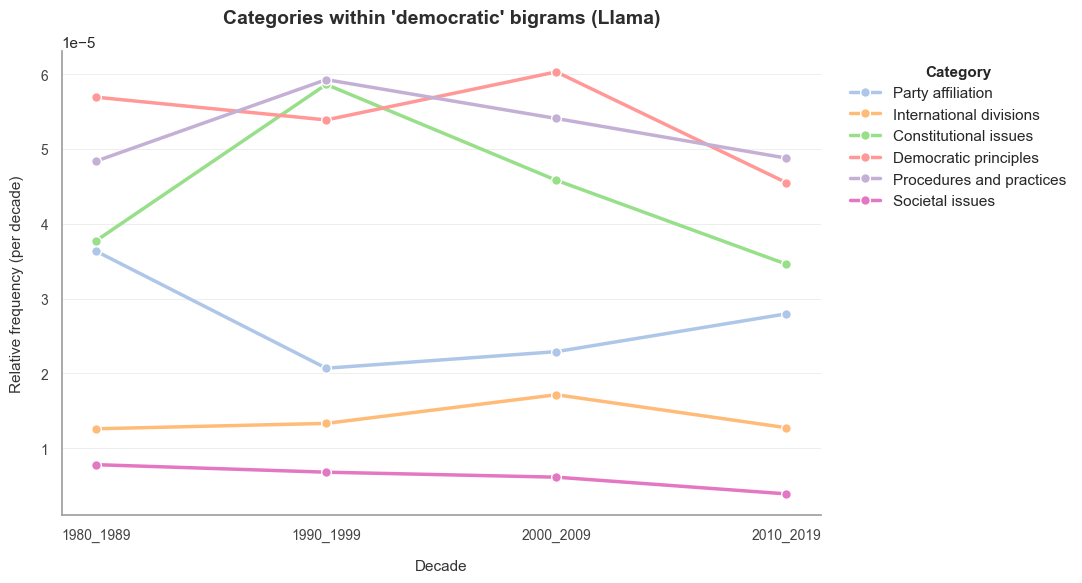

In [7]:
def plot_decade_corpus_relative_frequency_pretty(df, label_col, model_name):
    plot_df = df.dropna(subset=[label_col]).copy()
    
    plot_df[label_col] = plot_df[label_col].astype(int)
    plot_df["category"] = plot_df[label_col].map(category_names)
    
    grouped = (
        plot_df
        .groupby(["decade", "category"], as_index=False)
        .agg(
            category_count=("count", "sum"),
            total_decade_bigrams=("total_decade_bigrams", "first")
        )
    )
    
    grouped["relative_freq"] = (
        grouped["category_count"] /
        grouped["total_decade_bigrams"]
        )
    
    wide = grouped.pivot(
        index="decade",
        columns="category",
        values="relative_freq"
    ).fillna(0)
    
    wide = wide.reindex([
        "1980_1989",
        "1990_1999",
        "2000_2009",
        "2010_2019"
    ])
    
    # --- DISTINCT PASTEL LINE PLOT UPGRADES ---
    
    # 1. Set clean background style
    sns.set_theme(style="white")
    plt.figure(figsize=(11, 6), dpi=100)
    
    # 2. Match the exact distinct pastel palette from the bar chart
    distinct_pastels = [
        "#AEC7E8",  # Soft Sky Blue
        "#FFBB78",  # Pale Apricot
        "#98DF8A",  # Sage Green
        "#FF9896",  # Dusty Rose
        "#C5B0D5",  # Light Lavender
        "#E377C2"   # Soft Mauve/Pink
    ]
    
    # 3. Plot each category line with clean markers
    for idx, category in enumerate(category_names.values()):
        if category in wide.columns:
            plt.plot(
                wide.index,
                wide[category],
                marker="o",
                markersize=7,
                markeredgecolor="white",  # Gives markers a clean cutout feel
                markeredgewidth=1,
                linewidth=2.5,
                color=distinct_pastels[idx % len(distinct_pastels)],
                label=category
            )
    
    # 4. Clean background grids and spines
    ax = plt.gca()
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, color="#EBEBEB", linestyle="-", linewidth=0.6) # Horizontal grid lines
    ax.xaxis.grid(False) # Clear vertical lines for a more modern layout
    
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color("#A0A0A0")
    ax.spines["bottom"].set_color("#A0A0A0")
    
    # 5. Crisp Typography
    plt.title(f"Categories within 'democratic' bigrams ({model_name})", fontsize=14, pad=20, weight="bold", color="#2D2D2D")
    plt.xlabel("Decade", fontsize=11, labelpad=12, color="#333333")
    plt.ylabel("Relative frequency (per decade)", fontsize=11, labelpad=12, color="#333333")
    
    plt.xticks(rotation=0, fontsize=10, color="#444444")
    plt.yticks(fontsize=10, color="#444444")
    
    # 6. Perfect Legend Alignment
    plt.legend(
        bbox_to_anchor=(1.02, 1), 
        loc="upper left", 
        frameon=False,
        title="Category",
        title_fontproperties={"weight": "bold", "size": 11}
    )
    
    plt.tight_layout()
    plt.show()
    
    # Reset seaborn style to default
    sns.reset_orig()
    
    return grouped, wide


# Run the updated pretty function on your loop
decade_corpus_results = {}

for model_name, label_col in model_cols.items():
    grouped, wide = plot_decade_corpus_relative_frequency_pretty(
        merged_full,
        label_col,
        model_name
    )
    
    decade_corpus_results[model_name] = {
        "grouped": grouped,
        "wide": wide
    }